# SAMOS2026 Core3CS Project
### Group ASAYIKO
**Visualizing Remote-Sensed Ocean Colour Data**

Contributors: Koketso, Asanda, Yibanathi  
Date: May 2026



## Introduction
This project combines multiple methods to analyze and visualize oceanographic data. 
We use ESA-CCI Ocean Colour climatology to study chlorophyll concentration, alongside bathymetry data to understand physical drivers of phytoplankton distribution. 
By integrating maps, time series, and metadata analysis, we aim to highlight seasonal cycles and spatial variability in coastal regions.



## Mapping offshore bathymetry from St Helena Bay, Cape Columbine, and south past Cape Town

In [1]:
# Import packages
import xarray as xr
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np

# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

In [10]:
#Load bathymetry dataset downloaded from GMRT MapTool
bathy=xr.open_dataset('GMRTv4_4_1_20260513topo.grd')
bathy

<xarray.Dataset> Size: 41MB
Dimensions:   (lat: 3011, lon: 1706)
Coordinates:
  * lat       (lat) float64 24kB -34.06 -34.05 -34.05 ... -31.27 -31.27 -31.27
  * lon       (lon) float64 14kB 17.5 17.5 17.51 17.51 ... 19.38 19.38 19.38
Data variables:
    altitude  (lat, lon) float64 41MB ...
Attributes:
    title:        GMRT Grid
    history:      Projection: Cylindrical Equidistant\nExtracted from the Glo...
    Conventions:  COARDS,CF-1.6
    GMT_version:  4.5.7

### Obtained this module from Microsoft Copilot Ai

In [5]:
# Install cmocean module thay will be used for bathymetry colour representation
pip install cmocean

Note: you may need to restart the kernel to use updated packages.


In [14]:
# Import the package
import cmocean

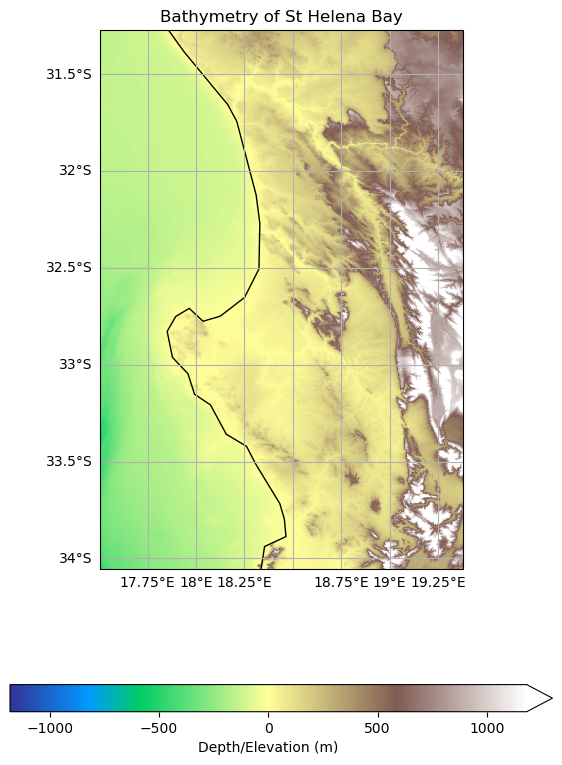

In [17]:
# Mapping bathymetry of the coastal region using the PlateCarree projection
fig, axis = plt.subplots(
    1, 1, figsize=(10, 10),
    subplot_kw=dict(projection=ccrs.PlateCarree())  
)

bathy['altitude'].plot(
    ax=axis,
    cmap='terrain',
    robust=True,
    cbar_kwargs={'orientation': 'horizontal', 'shrink: 0.7,
                 'label':'Depth/Elevation (m)'},
    transform=ccrs.PlateCarree()
)

# Add coastline colour and resolution
axis.coastlines(resolution='50m', color='black')

# Add gridlines but remove top/right labels
gl = axis.gridlines(draw_labels=True)
gl.top_labels = False   # remove top labels
gl.right_labels = False # remove right labels

plt.title('Bathymetry of St Helena Bay')
plt.show()

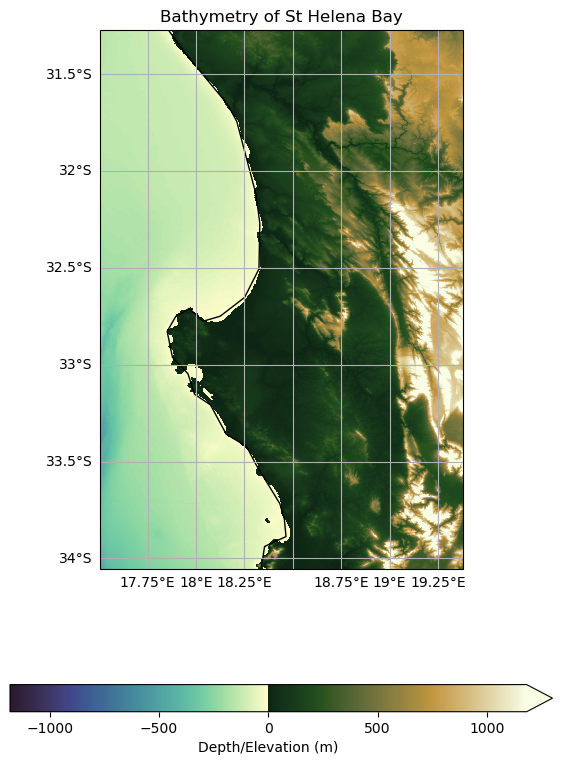

In [22]:
# Mapping bathymetry of the coastal region using the PlateCarree projection
fig, axis = plt.subplots(
    1, 1, figsize=(10, 10),
    subplot_kw=dict(projection=ccrs.PlateCarree())  # coastal region projection
)

# Plot bathymetry using cmocean's topo colormap
bathy['altitude'].plot(
    ax=axis,
    cmap=cmocean.cm.topo,           # correct colormap for bathymetry/topography
    robust=True,
    cbar_kwargs={"orientation": "horizontal", "shrink": 0.7,
                 'label':'Depth/Elevation (m)'},
    transform=ccrs.PlateCarree()
)        

# Add coastlines
axis.coastlines(resolution='50m', color='black')

# Gridlines with only left/bottom labels
gl = axis.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False

plt.title('Bathymetry of St Helena Bay')
plt.show()


In [4]:
import xarray as xr
# Load ESA-CCI chlorophyll climatology dataset
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# Display dataset information
chl



<xarray.Dataset> Size: 2GB
Dimensions:  (time: 12, lat: 4320, lon: 8640)
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...
Attributes: (12/53)
    CDI:                               Climate Data Interface version ?? (htt...
    history:                           Tue Apr 27 20:27:21 2021: cdo selvar,c...
    source:                            NASA SeaWiFS  L1A and L2 R2018.0 LAC a...
    institution:                       Plymouth Marine Laboratory
    Conventions:                       CF-1.7
    Metadata_Conventions:              Unidata Dataset Discovery v1.0
    ...                                ...
    time_coverage_start:               199801010000Z
    time_coverage_end:                 202001312359Z
    id:                                ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHL...
    NCO:                               4.7.2
    nco_openmp_thread_number:          1
    CDO:                               Climate Data Operators version 1.9.3 (...

In [3]:
import os
print(os.listdir("."))


['.ipynb_checkpoints', 'ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc', 'Exercise5.ipynb', 'GMRTv4_4_1_20260513topo.grd']


In [5]:
# Print dataset variables
print(chl.data_vars)


Data variables:
    crs      int32 4B ...
    chlor_a  (time, lat, lon) float32 2GB ...


In [7]:
# Identification of chlorophyll variable
possible_names = ['chlor_a', 'chlorophyll', 'CHL', 'chl']

for name in possible_names:
    if name in chl.data_vars:
        chlorophyll = chl[name]
        print(f"Using variable: {name}")
        break

# Display variable summary
chlorophyll

Using variable: chlor_a


<xarray.DataArray 'chlor_a' (time: 12, lat: 4320, lon: 8640)> Size: 2GB
[447897600 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 96B 1998-01-01 1998-02-01 ... 1997-12-01
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

In [8]:
# Compute annual mean chlorophyll concentration
annual_mean = chlorophyll.mean(dim='time')

annual_mean

<xarray.DataArray 'chlor_a' (lat: 4320, lon: 8640)> Size: 149MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(4320, 8640), dtype=float32)
Coordinates:
  * lat      (lat) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * lon      (lon) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
Attributes:
    standard_name:        mass_concentration_of_chlorophyll_a_in_sea_water
    long_name:            Chlorophyll-a concentration in seawater (not log-tr...
    units:                milligram m-3
    grid_mapping:         crs
    ancillary_variables:  chlor_a_log10_rmsd chlor_a_log10_bias
    parameter_vocab_uri:  http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU
    units_nonstandard:    mg m^-3

# Mean Annual Map of Chlorophyll-a

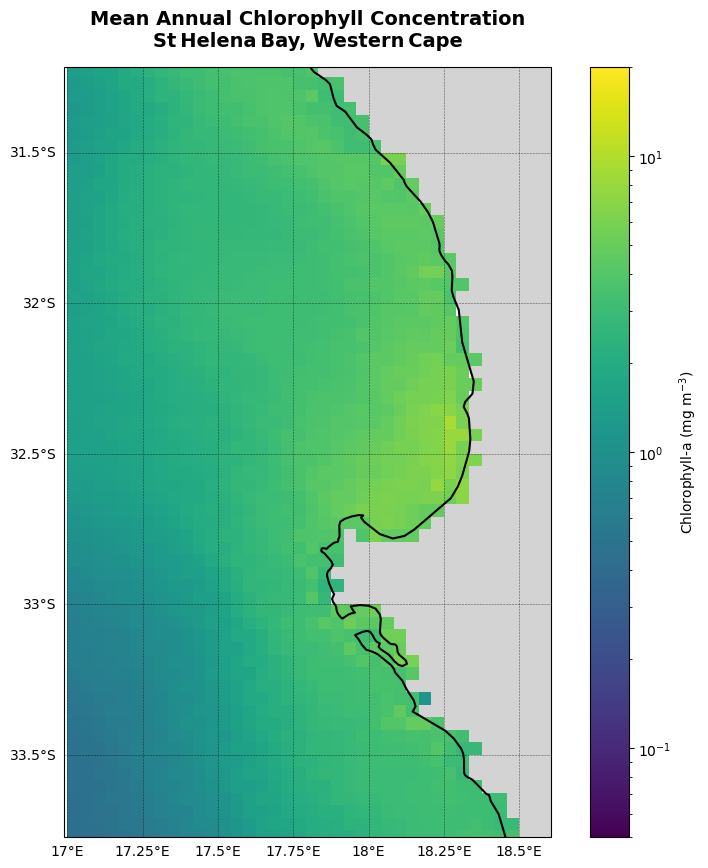

In [10]:
# Import libraries
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

# Define bounding box for St Helena Bay
lon_min, lon_max = 16.9876, 18.6069
lat_min, lat_max = -33.7727, -31.2160

# Handle latitude orientation automatically
if annual_mean.lat[0] > annual_mean.lat[-1]:

    st_helena = annual_mean.sel(lon=slice(lon_min, lon_max), lat=slice(lat_max, lat_min))
else:
    # Dataset stored south→north
    st_helena = annual_mean.sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))

# Mask invalid or zero values
st_helena = st_helena.where(st_helena > 0)

# Plot Settings
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())   # Standard lat/lon projection

# Plot chlorophyll with logarithmic color scale
plot = st_helena.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    norm=LogNorm(vmin=0.05, vmax=20),   # Log scale for better contrast
    cbar_kwargs={
        "label": "Chlorophyll-a (mg m$^{-3}$)"})

# Set map extent to region of interest
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# Coastlines, land shading, and borders
ax.coastlines(resolution='10m', linewidth=1.5, color='black')
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Gridlines with labels
gl = ax.gridlines(draw_labels=True, linewidth=0.4, linestyle='--', color='black', alpha=0.6)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

# Title
ax.set_title(
    'Mean Annual Chlorophyll Concentration\nSt Helena Bay, Western Cape',
    fontsize=14,
    weight='bold',
    pad=15
)

# Final map
plt.show()


## Time Series Analysis of Chlorophyll-a

To examine the seasonal variability of chlorophyll-a in St Helena Bay, we extract a 
regional subset of the ESA-CCI climatology bounded by 33.5°S–32.0°S and 17.5°E–19.0°E. 
The regional mean is computed by averaging all valid ocean pixels across this domain for 
each month, while a single grid point at 32.6°S, 17.7°E is selected to represent local 
variability. Both time series are plotted to compare the broader seasonal signal with 
point-scale dynamics. St Helena Bay is part of the Benguela Current upwelling system, 
where strong seasonal winds drive nutrient-rich cold water to the surface, fuelling 
elevated phytoplankton biomass — reflected here by peak chlorophyll concentrations in 
March–April and a summer minimum in July–August.

In [24]:
# Check lat direction
print("Lat min:", float(chl.lat.min()), "Lat max:", float(chl.lat.max()))
print("First few lat values:", chl.lat.values[:5])

# Check what the region actually contains
lat_min, lat_max = -33.5, -32.0
lon_min, lon_max = 17.5, 19.0

chl_region = chl['chlor_a'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))
print("Region shape:", chl_region.shape)
print("Non-NaN count:", int((~np.isnan(chl_region)).sum()))
print("Sample values:", chl_region.isel(time=0).values)

Lat min: -89.97916666666666 Lat max: 89.97916666666667
First few lat values: [89.97916667 89.9375     89.89583333 89.85416667 89.8125    ]
Region shape: (12, 36, 36)
Non-NaN count: 7368
Sample values: [[3.1443236 3.1443236 3.1738677 ...       nan       nan       nan]
 [3.164599  3.2525642 3.3181834 ...       nan       nan       nan]
 [3.3930354 3.387668  3.4434998 ...       nan       nan       nan]
 ...
 [2.282749  2.5949156 2.859337  ...       nan       nan       nan]
 [2.1002805 2.4757617 2.8258264 ...       nan       nan       nan]
 [2.1697457 2.5053596 2.5053596 ...       nan       nan       nan]]


Selected grid point: -32.65°S, 17.73°E
Regional mean values: [4.46  4.647 5.144 4.94  3.916 2.635 2.222 2.324 2.747 3.245 3.555 3.81 ]
Single point values:  [3.616 4.233 4.518 4.709 3.542 2.084 1.56  1.73  2.037 2.711 3.412 3.34 ]


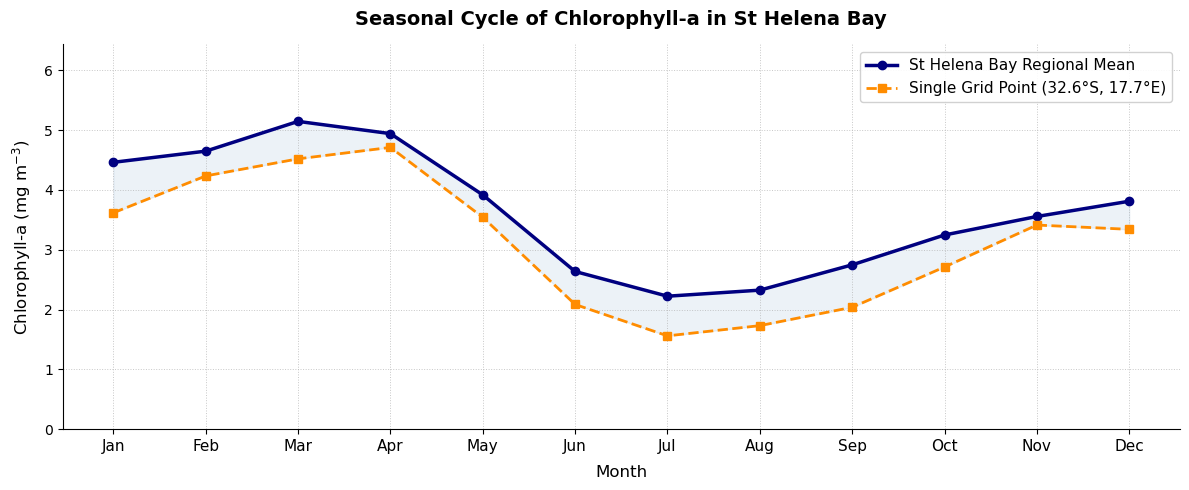

In [26]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Load dataset ──────────────────────────────────────────────────────────
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# ── 2. Define region (St Helena Bay) ─────────────────────────────────────────
lat_min, lat_max = -33.5, -32.0
lon_min, lon_max = 17.5, 19.0

# lat_max first because dataset latitude runs descending (90 → -90)
chl_region = chl['chlor_a'].sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)

# ── 3. Regional mean (ignores land/NaN pixels) ────────────────────────────────
chl_mean = chl_region.mean(dim=["lat", "lon"], skipna=True)

# ── 4. Find a valid single grid point inside the bay ─────────────────────────
# Scan the region at time=0 to find the first non-NaN ocean pixel
sample = chl['chlor_a'].isel(time=0).sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)
valid = np.argwhere(~np.isnan(sample.values))

if len(valid) == 0:
    raise ValueError("No valid ocean pixels found in region — check bounds")

# Pick a point roughly in the middle of valid pixels (more representative)
mid = valid[len(valid) // 2]
point_lat = float(sample.lat[mid[0]])
point_lon = float(sample.lon[mid[1]])
print(f"Selected grid point: {point_lat:.2f}°S, {point_lon:.2f}°E")

chl_point = chl['chlor_a'].sel(lat=point_lat, lon=point_lon, method="nearest")

# ── 5. Confirm values look sensible ──────────────────────────────────────────
print("Regional mean values:", np.round(chl_mean.values, 3))
print("Single point values: ", np.round(chl_point.values, 3))

# ── 6. Plot ───────────────────────────────────────────────────────────────────
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(1, 13)

mean_vals  = chl_mean.values
point_vals = chl_point.values

fig, ax = plt.subplots(figsize=(12, 5))

# Regional mean line
ax.plot(x, mean_vals,
        color='navy', linewidth=2.5,
        marker='o', markersize=6,
        label='St Helena Bay Regional Mean')

# Single grid point line
ax.plot(x, point_vals,
        color='darkorange', linewidth=2,
        linestyle='--', marker='s', markersize=6,
        label=f'Single Grid Point ({abs(point_lat):.1f}°S, {point_lon:.1f}°E)')

# Shaded band between the two lines
ax.fill_between(x, mean_vals, point_vals,
                alpha=0.10, color='steelblue')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11)
ax.set_xlabel("Month", fontsize=12, labelpad=8)
ax.set_ylabel("Chlorophyll-a (mg m$^{-3}$)", fontsize=12, labelpad=8)
ax.set_title("Seasonal Cycle of Chlorophyll-a in St Helena Bay",
             fontsize=14, fontweight='bold', pad=14)

# Safe y-axis upper limit
all_vals = np.concatenate([mean_vals, point_vals])
ymax = np.nanmax(all_vals) * 1.25
ymax = ymax if np.isfinite(ymax) else 8.0   # fallback
ax.set_ylim(0, ymax)

ax.legend(fontsize=11, framealpha=0.9, loc='upper right')
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chl_timeseries_StHelenaBay.png", dpi=300, bbox_inches='tight')
plt.show()

**Figure 3:** Seasonal cycle of chlorophyll-a concentration (mg m⁻³) in St Helena Bay 
(17.5°–19.0°E, 33.5°–32.0°S) derived from ESA-CCI Ocean Colour climatology (1998–2020). 
The navy line shows the spatial mean over the region; the orange dashed line represents 
a single grid point at 32.6°S, 17.7°E. The shaded area highlights the difference between 
regional and local variability. Peak concentrations in March–April reflect enhanced 
phytoplankton growth associated with Benguela upwelling.